# Freight Rate Prediction
Complete ML Pipeline broken down into testable cells.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

## 1. Data Loading

In [42]:
df_train = pd.read_csv('train-test.csv')
df_val = pd.read_csv('validation.csv')
df_december = pd.read_csv('december-chart-inputs.csv')
print(f'Training data: {df_train.shape}')
df_train.head()

Training data: (48000, 14)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [43]:
df_train.isna().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [44]:
(df_train['weight']<0).sum()


np.int64(292)

## 2. EDA & Cleaning

In [45]:
df_train = df_train[df_train['distance'] > 0] # checked that all of them are postive 
df_train['weight'] = df_train['weight'].abs() # since we had negative weights which doesnt make sense 
print('Cleaning complete.')

Cleaning complete.


## 3. Imputation

In [46]:
# Show all rows where the 'weight' column is missing
missing_weights_df = df_train[df_train['weight'].isnull()]

print(f"Total rows with missing weights: {len(missing_weights_df)}")
missing_weights_df


Total rows with missing weights: 300


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
323,TR-000324,Richmond,San Francisco,38.09122,-76.78906,35.19670,-121.69849,2848.8,Reefer,NaN,2025-01-03,0.91370,1.92679,5430.07
648,TR-000649,Tulsa,Mobile,33.45894,-94.78556,31.80442,-88.25195,467.0,Reefer,NaN,2025-01-05,0.77536,2.48162,1178.03
694,TR-000695,Los Angeles,Fresno,28.56624,-116.70249,33.07921,-119.79528,432.6,Reefer,NaN,2025-01-05,0.84069,2.37036,1022.13
732,TR-000733,El Paso,Hartford,33.31075,-110.31230,39.55328,-72.18051,2497.6,Reefer,NaN,2025-01-05,0.79026,2.01004,4991.60
911,TR-000912,Washington,Kansas City,38.87577,-77.05086,39.41104,-91.12450,887.8,Dry Van,NaN,2025-01-06,0.81120,1.85853,1643.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47473,TR-047474,Philadelphia,Columbia,39.22317,-72.96710,34.63570,-83.28506,774.0,Flatbed,NaN,2025-10-28,0.93722,1.86721,1745.58
47478,TR-047479,Montgomery,Phoenix,31.37602,-86.10743,28.75668,-115.87725,2101.8,Dry Van,NaN,2025-10-28,0.94401,2.15227,4115.49
47582,TR-047583,Reno,Milwaukee,39.54838,-118.64843,39.62180,-88.48008,1852.6,Flatbed,NaN,2025-10-29,0.98255,2.10315,3789.30
47700,TR-047701,Kansas City,Shreveport,39.41104,-91.12450,32.54628,-92.31888,570.8,Dry Van,NaN,2025-10-30,1.02462,1.98408,1262.99


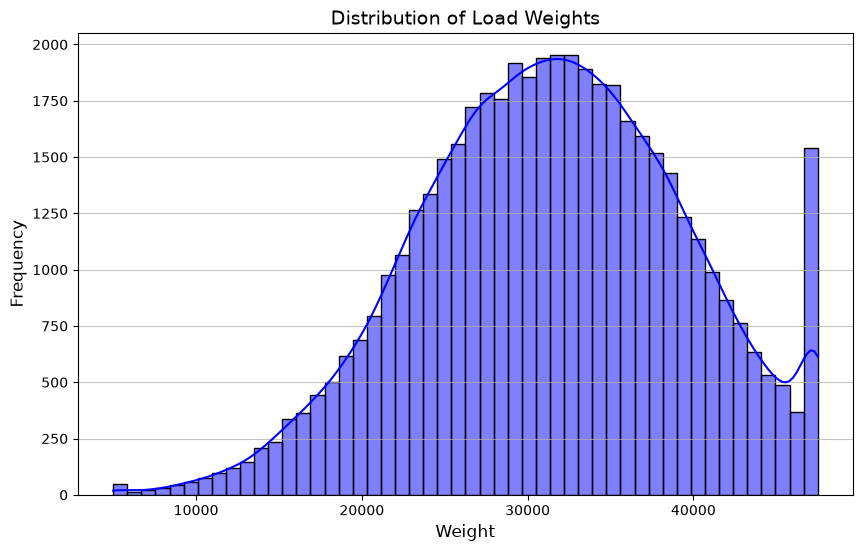

Weight Summary Statistics:
count    47700.000000
mean     31417.249245
std       7996.515399
min       5000.000000
25%      25922.000000
50%      31496.000000
75%      37063.250000
max      47500.000000
Name: weight, dtype: float64


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Using seaborn to plot the distribution of weights, ignoring NaNs
sns.histplot(df_train['weight'].dropna(), bins=50, kde=True, color='blue')

plt.title('Distribution of Load Weights', fontsize=14)
plt.xlabel('Weight', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

# Print basic statistics for the weight column
print("Weight Summary Statistics:")
print(df_train['weight'].describe())


In [48]:
WEIGHT_MEDIAN = df_train['weight'].median()
df_train['weight'] = df_train['weight'].fillna(WEIGHT_MEDIAN)

In [50]:
# Show rows with missing market_index
missing_market_df = df_train[df_train['market_index'].isnull()]
print(f"Total rows with missing market_index: {len(missing_market_df)}")
missing_market_df.head()

Total rows with missing market_index: 374


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
116,TR-000117,Memphis,Fort Wayne,35.56802,-89.52871,41.31561,-85.36206,533.8,Reefer,30570.0,2025-01-01,NaN,2.37177,1271.10
226,TR-000227,Tampa,Hartford,28.35765,-86.94782,39.55328,-72.18051,1342.7,Reefer,26397.0,2025-01-02,NaN,2.01837,2743.13
311,TR-000312,Los Angeles,New York,28.56624,-116.70249,40.00674,-73.79840,2935.7,Flatbed,32807.0,2025-01-02,NaN,1.91236,5568.57
511,TR-000512,Grand Rapids,Amarillo,43.43800,-86.29173,33.17137,-104.36789,1420.7,Reefer,19360.0,2025-01-04,NaN,1.94596,2786.63
531,TR-000532,Richmond,San Antonio,38.09122,-76.78906,29.50969,-98.40059,1624.7,Reefer,39452.0,2025-01-04,NaN,2.04970,3295.80


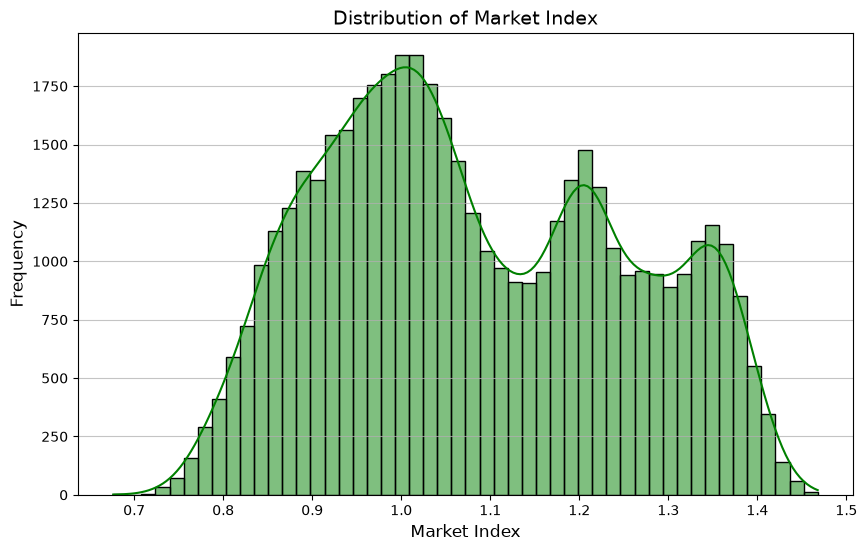

Market Index Summary Statistics:
count    47626.000000
mean         1.083387
std          0.168091
min          0.676390
25%          0.949670
50%          1.055800
75%          1.219590
max          1.467780
Name: market_index, dtype: float64


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Plot the distribution of market_index, ignoring NaNs
sns.histplot(df_train['market_index'].dropna(), bins=50, kde=True, color='green')

plt.title('Distribution of Market Index', fontsize=14)
plt.xlabel('Market Index', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

# Print basic statistics for the market_index column
print("Market Index Summary Statistics:")
print(df_train['market_index'].describe())


In [52]:
# Group by date to see how many missing market indices there are per day
missing_by_date = df_train[df_train['market_index'].isnull()]['date'].value_counts()

print(f"Number of unique dates with missing market indices: {len(missing_by_date)}")
print("\nTop 10 dates with the most missing market indices:")
print(missing_by_date.head(10))


Number of unique dates with missing market indices: 209

Top 10 dates with the most missing market indices:
date
2025-06-15    5
2025-07-27    5
2025-01-26    4
2025-02-28    4
2025-03-28    4
2025-04-15    4
2025-05-20    4
2025-05-31    4
2025-06-16    4
2025-10-02    4
Name: count, dtype: int64


In [53]:
# 1. First, calculate the average market index for the specific Date + Pickup City
city_daily_market = df_train.groupby(['date', 'pickup'])['market_index'].transform('mean')
df_train['market_index'] = df_train['market_index'].fillna(city_daily_market)

daily_market = df_train.groupby('date')['market_index'].transform('mean')
df_train['market_index'] = df_train['market_index'].fillna(daily_market)


In [54]:
df_train.isnull().sum()

load_id         0
pickup          0
delivery        0
pickup_lat      0
pickup_lon      0
delivery_lat    0
delivery_lon    0
distance        0
equipment       0
weight          0
date            0
market_index    0
quote_signal    0
posted_rate     0
dtype: int64

## 4. Feature Engineering: Dates

In [55]:
def engineer_dates(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['day_of_year'] = df['date'].dt.dayofyear
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
    return df
df_train = engineer_dates(df_train)

## 5. Feature Engineering: Geography

In [56]:
def engineer_geography(df):
    df = df.copy()
    df['lat_diff'] = df['delivery_lat'] - df['pickup_lat']
    df['lon_diff'] = df['delivery_lon'] - df['pickup_lon']
    df['geo_distance'] = np.sqrt(df['lat_diff']**2 + df['lon_diff']**2)
    df['log_distance'] = np.log1p(df['distance'])
    return df
df_train = engineer_geography(df_train)

## 6. Feature Engineering: Interactions

In [57]:
def engineer_interactions(df):
    df = df.copy()
    df['rate_per_mile_signal'] = df['quote_signal'] * df['distance']
    df['distance_x_weight'] = df['distance'] * df['weight']
    df['distance_x_signal'] = df['distance'] * df['quote_signal']
    return df
df_train = engineer_interactions(df_train)

## 7. Feature Engineering: Encoding

In [58]:
df_train

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,...,day_of_year,day_sin,day_cos,lat_diff,lon_diff,geo_distance,log_distance,rate_per_mile_signal,distance_x_weight,distance_x_signal
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,...,1,0.017213,0.999852,0.07786,4.04342,4.044170,5.617861,657.209085,8409489.4,657.209085
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,...,1,0.017213,0.999852,1.13195,3.82196,3.986062,5.640132,682.610775,4924177.5,682.610775
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,...,1,0.017213,0.999852,5.07979,-14.56161,15.422216,6.876058,1785.503898,30699583.8,1785.503898
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,...,1,0.017213,0.999852,-4.70395,-14.10889,14.872388,6.873578,1812.171648,31214278.2,1812.171648
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,...,1,0.017213,0.999852,3.46454,6.29428,7.184775,6.296925,1388.889700,19065667.7,1388.889700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47995,TR-047996,Reno,Baton Rouge,39.54838,-118.64843,30.50134,-92.65374,1830.9,Flatbed,31786.0,...,304,-0.867456,0.497513,-9.04704,25.99469,27.524041,7.513109,3764.806434,58196987.4,3764.806434
47996,TR-047997,Greensboro,Memphis,35.98195,-82.78379,35.56802,-89.52871,445.8,Reefer,37465.0,...,304,-0.867456,0.497513,-0.41393,-6.74492,6.757609,6.102111,677.549130,16701897.0,677.549130
47997,TR-047998,Greensboro,Cincinnati,35.98195,-82.78379,37.15706,-86.77499,267.9,Flatbed,24528.0,...,304,-0.867456,0.497513,1.17511,-3.99120,4.160596,5.594340,393.689766,6571051.2,393.689766
47998,TR-047999,Memphis,Reno,35.56802,-89.52871,39.54838,-118.64843,1901.3,Flatbed,37581.0,...,304,-0.867456,0.497513,3.98036,-29.11972,29.390498,7.550819,3900.174716,71452755.3,3900.174716


In [ ]:
le_pickup = LabelEncoder()
le_delivery = LabelEncoder()
le_equipment = LabelEncoder()
def encode_categoricals(df, fit=False):
    df = df.copy()
    if fit:
        df['pickup_enc'] = le_pickup.fit_transform(df['pickup'])
        df['delivery_enc'] = le_delivery.fit_transform(df['delivery'])
        df['equipment_enc'] = le_equipment.fit_transform(df['equipment'])
    else:
        df['pickup_enc'] = df['pickup'].map(lambda x: le_pickup.transform([x])[0] if x in le_pickup.classes_ else -1)
        df['delivery_enc'] = df['delivery'].map(lambda x: le_delivery.transform([x])[0] if x in le_delivery.classes_ else -1)
        df['equipment_enc'] = df['equipment'].map(lambda x: le_equipment.transform([x])[0] if x in le_equipment.classes_ else -1)
    return df
df_train = encode_categoricals(df_train, fit=True)

## 8. Final Feature Matrix

In [ ]:
feature_cols = ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'day_of_week', 'month', 'day_sin', 'day_cos', 'lat_diff', 'lon_diff', 'geo_distance', 'log_distance', 'rate_per_mile_signal', 'distance_x_weight', 'distance_x_signal', 'pickup_enc', 'delivery_enc', 'equipment_enc']
X = df_train[feature_cols].values
y = df_train['posted_rate'].values
X = np.nan_to_num(X, nan=0.0)
print(f'Feature matrix shape: {X.shape}')

## 9. Train/Test Split & Modeling

In [ ]:
dates = df_train['date'].values
sorted_idx = np.argsort(dates)
split_point = int(len(sorted_idx) * 0.8)
train_idx, test_idx = sorted_idx[:split_point], sorted_idx[split_point:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
try:
    from xgboost import XGBRegressor
except:
    pass
try:
    from lightgbm import LGBMRegressor
except:
    pass
from sklearn.metrics import mean_absolute_error
import time

models_and_params = {
    "Extra Trees": {
        "model": ExtraTreesRegressor(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 15, 20, None],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 15, 20, None],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [5, 7],
            "learning_rate": [0.05, 0.1]
        }
    }
}

if 'XGBRegressor' in globals():
    models_and_params["XGBoost"] = {
        "model": XGBRegressor(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 7, 9],
            "learning_rate": [0.01, 0.05, 0.1]
        }
    }

if 'LGBMRegressor' in globals():
    models_and_params["LightGBM"] = {
        "model": LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 7, 9],
            "learning_rate": [0.01, 0.05, 0.1]
        }
    }

best_overall_model = None
best_overall_mae = float('inf')
best_overall_name = ""
tuned_results = {}

print("🚀 Starting Hyperparameter Tuning for Models...\n")

for name, mp in models_and_params.items():
    print(f"[{name}] Starting tuning...")
    start_time = time.time()
    
    search = RandomizedSearchCV(
        mp["model"], 
        param_distributions=mp["params"], 
        n_iter=5, 
        cv=3, 
        scoring='neg_mean_absolute_error', 
        random_state=42, 
        n_jobs=1 
    )
    
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    
    preds = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    elapsed_time = time.time() - start_time
    
    tuned_results[name] = {"model": best_model, "mae": mae, "params": search.best_params_}
    
    print(f"[{name}] ✅ Done in {elapsed_time:.1f}s | Test MAE: ${mae:.2f}")
    print(f"[{name}] Best Params: {search.best_params_}\n")
    
    if mae < best_overall_mae:
        best_overall_mae = mae
        best_overall_model = best_model
        best_overall_name = name

print("="*60)
print(f"🏆 WINNING MODEL: {best_overall_name}")
print(f"🏆 WINNING MAE: ${best_overall_mae:.2f}")
print("="*60)

final_model = best_overall_model
print("Retraining best model on full dataset...")
final_model.fit(X, y)
print("Done.")

## 10. Generate Final Predictions

In [ ]:
# Recalculate medians directly from the training dataset
train_market_median = df_train["market_index"].median()
train_signal_median = df_train["quote_signal"].median()

df_dec_clean = df_december.copy()

# Fill fixed values for Lexington -> Fort Wayne using exact coordinates from training
df_dec_clean["pickup_lat"] = 36.99152
df_dec_clean["pickup_lon"] = -84.99876
df_dec_clean["delivery_lat"] = 41.31561
df_dec_clean["delivery_lon"] = -85.36206
df_dec_clean["market_index"] = train_market_median
df_dec_clean["quote_signal"] = train_signal_median

df_dec_clean["pickup"] = "Lexington"
df_dec_clean["delivery"] = "Fort Wayne"

# We must ensure equipment and weight match the test requirement
df_dec_clean["equipment"] = "Dry Van"
df_dec_clean["weight"] = 32000.0

# Engineering
df_dec_clean = engineer_dates(df_dec_clean)
df_dec_clean = engineer_geography(df_dec_clean)
df_dec_clean = engineer_interactions(df_dec_clean)
df_dec_clean = encode_categoricals(df_dec_clean, fit=False)

X_dec = df_dec_clean[feature_cols].values
X_dec = np.nan_to_num(X_dec, nan=0.0)

dec_preds = final_model.predict(X_dec)
dec_preds = np.maximum(dec_preds, 1.0)

df_december["predicted_rate"] = dec_preds
df_december.to_csv("december-chart-inputs.csv", index=False)
print("Saved december-chart-inputs.csv")

In [ ]:
!python score.py --predictions validation_predictions.csv --december-predictions december-chart-inputs.csv